# Important resources to implement
- [ ] To update the graph and route at the same time (Command): https://langchain-ai.github.io/langgraph/how-tos/command/
- [ ] To get React agent and structured output in two calls: https://langchain-ai.github.io/langgraph/how-tos/react-agent-structured-output/
- [ ] To develop react agent: https://langchain-ai.github.io/langgraph/how-tos/react-agent-from-scratch/
- [ ] Command to update state and giving instruction for the next node: https://blog.langchain.dev/command-a-new-tool-for-multi-agent-architectures-in-langgraph/

In [32]:
import argparse
import datetime
import json
import random
import logging
import os
import re
import ast'
import io
import sys
import duckdb
import tqdm
import numpy as np
from functools import wraps
from IPython.display import Image, display
from pprint import pprint

from utils.utils import dynamic_import, load_config
from langchain_ollama import OllamaLLM, ChatOllama

from typing import Annotated, Union, Optional, List, Literal, Callable

from typing_extensions import TypedDict, Literal
from pydantic import BaseModel, field_validator, ValidationError, Field, model_validator

# from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, AnyMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.tools import BaseTool, tool
from langgraph.types import Command
from langchain_openai import ChatOpenAI

In [33]:
from importlib.metadata import version
import langgraph
version("langgraph")

'0.2.70'

In [34]:
def setup_logger() -> logging.Logger:
    """Setup the logger configuration for consistency."""
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
        handlers=[logging.StreamHandler()],
    )
    return logging.getLogger(__name__)


logger = setup_logger()

## Get the data from the db

In [35]:
def get_text_from_db(conn, table_sections, pmcid):
    """
    Get the already recorded pmcids from db
    """
    cursor = conn.cursor()
    query = f"""
        SELECT abstract, SUBJECTS, METHODS
        FROM {table_sections} 
        WHERE pmcid = ?
    """
    cursor.execute(query, (pmcid,))
    row = cursor.fetchone()
    cursor.close()
    if row:
        abstract, subjects, method = row
        return abstract, subjects, method
    else:
        return None, None, None

In [36]:
# Load config
config_path = os.path.join("../config", "config.yaml")
config_all = load_config(config_path)

# DB connection
# # Name of the database
DB_FILE = config_all["api_europepmc_params"]["db_info_articles"]
table_status = config_all["db_params"]["table_status"]
table_sections = config_all["db_params"]["table_sections"]
table_metadata = config_all["db_params"]["table_metadata"]
table_inference = config_all["db_params"]["table_inference"]
# # Using duckdb to access the sqlite file for compatibility on marenostrum
conn = duckdb.connect(f"../{DB_FILE}")

# List of PMCID for testing
list_pmcids = [
    'PMC10167034', 'PMC10191296', 'PMC10262854', 'PMC10390885', 'PMC10451945',
    'PMC1368980',  'PMC2383879',  'PMC2693442',  'PMC3016279',  'PMC3041764',
    'PMC3145824',  'PMC3174812',  'PMC3212907',  'PMC3219398',  'PMC3308973',
    'PMC3446531',  'PMC3534646',  'PMC3619104',  'PMC3804564',  'PMC3909226',
    'PMC4006427',  'PMC4023701',  'PMC4029655',  'PMC4065281',  'PMC4152203',
    'PMC4221596',  'PMC4251014',  'PMC4344476',  'PMC4393161',  'PMC4492682',
    'PMC4596022',  'PMC4640153',  'PMC4928460',  'PMC5040013',  'PMC5053679',
    'PMC5076567',  'PMC5087213',  'PMC5137654',  'PMC5149569',  'PMC5253404',
    'PMC5308745',  'PMC5425199',  'PMC5441889',  'PMC5601641',  'PMC5645380',
    'PMC5717332',  'PMC5784259',  'PMC5839230',  'PMC5961641',  'PMC6060212',
    'PMC6076250',  'PMC6145291',  'PMC6160275',  'PMC6248768',  'PMC6286024',
    'PMC6730009',  'PMC6760014',  'PMC6775309',  'PMC6853912',  'PMC6858051',
    'PMC6955584',  'PMC7007877',  'PMC7011053',  'PMC7436656',  'PMC7449478',
    'PMC7537889',  'PMC7550220',  'PMC7657407',  'PMC7661891',  'PMC7722655',
    'PMC7722817',  'PMC7734296',  'PMC7882770',  'PMC7903471',  'PMC7906844',
    'PMC7956942',  'PMC8155599',  'PMC8288503',  'PMC8382172',  'PMC8456091',
    'PMC8723790',  'PMC8752710',  'PMC8771850',  'PMC8976245',  'PMC9028212',
    'PMC9081438',  'PMC9138181',  'PMC9305770',  'PMC9333080',  'PMC9381901',
    'PMC9413660',  'PMC9422814',  'PMC9529122',  'PMC9537611',  'PMC9601430',
    'PMC9616492',  'PMC9636513',  'PMC9683380',  'PMC9697589'
]
pmcid_method = list()
for pmcid in tqdm.tqdm(list_pmcids[0:10]):
    
    abstract, subjects, method = get_text_from_db(conn, table_sections, pmcid)
    pmcid_method.append({'pmcid': pmcid, 'abstract': abstract, 'method': method, 'subjects': subjects})

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:49<00:00, 10.96s/it]


In [4]:
# Tools
@tool
def extract_section_tool(document: dict, section: str) -> str:
    """
    Extracts a specific section (e.g., 'Abstract', 'Method', 'Result') from a single document dictionary.
    If the section does not exist, returns an empty string.
    """
    return document.get(section, "No content available.")

In [5]:
bsc = False

host = "http://0.0.0.0"
api_end = 'v1'

if bsc is True:
    model_name = '/gpfs/projects/bsc02/llm_models/huggingface_models/Mistral-Small-24B-Instruct-2501'
    port = "11434"
    openai_api_base = f"{host}:{port}/{api_end}"

    llm = ChatOpenAI(openai_api_base=openai_api_base, 
                     openai_api_key='dummy',
                     model_name=model_name,
                     temperature=1)
else:
    model_name = "phi4"
    port = "11434"
    openai_api_base = f"{host}:{port}/{api_end}"
    llm = ChatOpenAI(openai_api_base=openai_api_base, 
                     openai_api_key='dummy',
                     model=model_name,
                     temperature=1)
print(llm.invoke('Barcelona is'))

INFO:httpx:HTTP Request: POST http://0.0.0.0:11434/v1/chat/completions "HTTP/1.1 200 OK"


content="Barcelona is a vibrant and cosmopolitan city located in northeastern Spain, within the autonomous community of Catalonia. It's renowned for its rich cultural heritage, stunning architecture, and historical landmarks.\n\n### Key Highlights:\n\n1. **Architecture**: Barcelona is famous for Antoni Gaudí's architectural masterpieces, such as the Sagrada Família, Park Güell, Casa Batlló, and Casa Milà (La Pedrera). The unique style of these buildings is known as Catalan Modernism.\n\n2. **Art and Culture**: The city was home to prominent artists like Pablo Picasso and Joan Miró. Museums such as the Picasso Museum, Joan Miró Foundation, and the National Art Museum of Catalonia offer extensive art collections.\n\n3. **Catalan Charm**: Barcelona has a distinctive cultural identity with its own language (Catalan) and traditions that contribute to the city's unique atmosphere.\n\n4. **Food and Gastronomy**: The region offers an impressive culinary scene, including famous tapas bars and s

In [6]:
# States
class PrivateState(BaseModel):
    pass
    
class DecisionState(BaseModel):
    article: dict = {}
    answer_context: dict = Field(
        default_factory=dict,
        description="Context of the decision process from the agent"
    )
    human_presence: bool = Field(default=False, description="Does the article contain information about human subjects")
    participant_demographics: bool = Field(default=False, description ="Does the article contains information about participants demographics")
    sex_specific_phenotype: bool = Field(default=False, description="Does the article contains information about the sex of the subjects")
    multi_samples: bool = Field(default=False, description="Does the research involves several samples")
    #one_subject: bool = Field(default=False, description="Does the samples provides from the same subject")   
    multi_cohorts: bool = Field(default=False, description="Are there several cohorts")
    cohorts_overlap: bool = Field(default=False, description="Are some subjects present in more than one cohort")
    dropouts_before: bool = Field(default=False, description="Are there participants who drop the studies before the research started")
    dropouts_during: bool = Field(default=False, description="Are there participants who drop the studies during the research")
    droupouts_after: bool = Field(default=False, description="Are there participants who drop the studies after the research")
    info_text: bool = Field(default=False, description="Is the information contained in the text")
    info_table: bool = Field(default=False, description="Is the information contained in table")


class ResultResponse(BaseModel):
    n_male: float = Field(default=np.nan, description="The total number of unique male reported in the paper")
    n_female: float = Field(default=np.nan, description="The total number of unique female reported in the paper")
    n_sample: float = Field(default=np.nan, description="The total number of unique participants reported in the paper")


class FinalResponse(BaseModel):
    final_output: Union[DecisionState, ResultResponse]

In [7]:
# Pydantic parsers
from pydantic import BaseModel, Field, model_validator
import json
import ast

class BooleanParser(BaseModel):
    answer: bool = Field(description="Must be either 'True' or 'False'")
    
    @model_validator(mode="before")
    @classmethod
    def preprocess_input(cls, values: dict) -> dict:
        raw_answer = values.get("answer")
        
        if isinstance(raw_answer, str):
            # Clean and convert string if necessary
            raw_answer = cls._clean_and_convert_string(raw_answer)
        
        # Handle case where raw_answer is a dictionary with an 'answer' field
        if isinstance(raw_answer, dict) and "answer" in raw_answer:
            raw_answer = raw_answer["answer"]
        
        # If it's still a string, check for valid "true"/"false" values
        if isinstance(raw_answer, str):
            stripped_answer = raw_answer.strip().lower()
            if stripped_answer in ("true", "false"):
                raw_answer = stripped_answer == "true"
        
        # If the answer is neither boolean nor string, raise an error
        if not isinstance(raw_answer, bool):
            raise ValueError(f"Answer must be 'True' or 'False', got: {raw_answer}")
        
        values["answer"] = raw_answer
        return values

    @staticmethod
    def _clean_and_convert_string(raw_answer: str) -> any:
        raw_answer = raw_answer.strip("`").strip()
        
        if raw_answer.startswith('```json') and raw_answer.endswith('```'):
            # Remove the ```json``` markers
            raw_answer = raw_answer[7:-3].strip()

        # Replace 'True'/'False' to lowercase for uniformity
        raw_answer = raw_answer.replace("True", "true").replace("False", "false")
        
        try:
            # Try to parse as JSON
            raw_answer = json.loads(raw_answer)
        except json.JSONDecodeError:
            try:
                # Try to evaluate as a Python literal
                raw_answer = ast.literal_eval(raw_answer)
            except (ValueError, SyntaxError):
                print(f"Failed to parse raw_answer: {raw_answer}")
                pass
        
        return raw_answer
    
    @model_validator(mode="after")
    @classmethod
    def validate_answer(cls, model: "BooleanParser") -> "BooleanParser":
        if not isinstance(model.answer, bool):
            raise ValueError(f"Answer must be a boolean (True or False), got: {model.answer}")
        return model
    
    
class ContextParser(BooleanParser):
    context: List[str] = Field(default_factory=list, description="Relevant sentences or data supporting the decision")

    @model_validator(mode="before")
    @classmethod
    def preprocess_input(cls, values: dict) -> dict:
        # First, handle BooleanParser preprocessing
        values = super().preprocess_input(values)

        # Additional preprocessing for context
        raw_context = values.get("context", [])
        if isinstance(raw_context, str):
            values["context"] = [raw_context.strip()]
        elif isinstance(raw_context, list):
            values["context"] = [item.strip() for item in raw_context if isinstance(item, str)]
        else:
            raise ValueError(f"Context must be a string or a list of strings, got: {type(raw_context)}")

        return values

In [8]:
# Helper to add context information
def add_context(state: DecisionState, node: str, context_answer: str) -> DecisionState:
    # Update the answer_context dictionary by adding or updating the entry for the current node
    state.answer_context[node] =  context_answer
    return state


In [43]:
def process_bool_decision(state, task_description, result_key, *nodes) -> Command[Union[str, List[str]]]:
    #print(f'Inside the {result_key} node')
    system_message = """
    You are a helpful assistant analyzing a scientific article.
    You can call tools to extract specific sections of the document.
    """
    parser = PydanticOutputParser(pydantic_object=ContextParser)

    for section, section_content in state.article.items():
        if section_content in [None, "No content available."] or section.lower() == 'pmcid':
            continue  # Skip invalid sections

        chat_prompt = ChatPromptTemplate.from_messages([
            ("system", system_message),
            ("user", task_description)
        ])

        prompt_messages = chat_prompt.format_messages(
            section_header=section,
            section_content=section_content,
            format_instructions=parser.get_format_instructions()
        )

        response = llm.invoke(prompt_messages)

        try:
            parsed_response = parser.invoke(response.content.strip())

            if parsed_response.answer:
                context = state.answer_context
                context[result_key] = {section: parsed_response.context}
                goto_decision = node[0]
                #return {result_key: parsed_response.answer, "answer_context": context}
                update = {result_key: parsed_response.answer, "answer_context": context}
            else: 
                goto_decision = nodes[1]
                update = {result_key: False}
        except ValueError as e:
            print(f"Error in {result_key} node: {response}")
            raise ValueError("Validation failed for model: " + str(e))

    return Command(update=update, goto=goto_decision)

In [44]:
# Decorator to handle multiple nodes
def with_nodes(*nodes: str):
    def decorator(func: Callable):
        @wraps(func)
        def wrapper(state, *args, **kwargs):
            # Call the original function with the provided nodes
            return func(state, *nodes, *args, **kwargs)

        # Modify the type hints for static analysis or documentation
        wrapper.__annotations__['return'] = Command[Union[Literal[*nodes]]]

        return wrapper
    return decorator



In [47]:
@with_nodes("sex_specific_phenotype_node", "final_response_node")
def human_presence(state: DecisionState, *nodes: str):
    task_description = """
    Your task is to determine if the article involves a study on human subjects. 
    Focus on the following section: {section_header} of the document: {section_content}
    
    Respond with:
    - 'True': If the document explicitly mentions human subjects.
    - 'False': If the document does not mention human subjects or lacks enough information for a clear decision.

    Important: Follow the format instructions exactly:\n\n{format_instructions}. 
    Fully respect the format_instruction and do not provide any additional information beyond what is requested.
    """
    return process_bool_decision(state, task_description, "human_presence", nodes[0], nodes[1])

@with_nodes("participant_demographics_node", "final_response_node")
def sex_specific_phenotype(state: DecisionState, *nodes: str):
    task_description = """
    The article discusses experiments involving individual human subjects. 
    Your task is to determine if the study involves sex-specific phenotypes only. 
    Focus on the following section: {section_header} of the document: {section_content} 
    
    Respond with:
    - 'True': If the document contains sex specific phenotype. 
    - 'False': If the document does not contain sex specific phenotype.
    
    Here are two illustrative examples to guide you in the task:

    Example 1: 
    - Text: The study explored the genetic markers associated with breast cancer. Researchers identified hormonal influences unique participants physiology that contribute to the development and progression of the disease.
    - Response: True
    Example 2: 
    - Text: The research examined cognitive decline patterns in Alzheimer's disease across various age groups. 
    - Response: False
    
    If the answer is 'True', include relevant sentences or table excerpts from the section that support your decision in the 'context' field.
    
    Important: Follow the format instructions exactly:\n\n{format_instructions}. 
    Fully respect the format_instruction and do not provide any additional information beyond what is requested.
    """
    return process_bool_decision(state, task_description, "sex_specific_phenotype",  nodes[0], nodes[1])


@with_nodes("multi_samples_node", "final_response_node")
def participant_demographics(state: DecisionState, *nodes: str):
    task_description = """
    The article discusses experiments involving individual human subjects. 
    Your task is to determine the presence of information about the number of participants and whether it is disaggregated by sex or gender in the section. 
    Focus on the following section: {section_header} of the document: {section_content} 
    
    Respond with:
    - 'True': If the document contains information to know if some participants are males or females or if the information about the gender is given. Even if only one gender or sex can be inferred, answer True
    - 'False': If the document does not contain information about the sex or the gender of the participants.
    
    Here are two illustrative examples to guide you in the task:

    Example 1: 
    - Text: The study included 50 participants, comprising 30 females and 20 males, aged between 20 to 35 years.
    - Response: True
    Example 2: 
    - Text: "This research involved a cohort of individuals who participated in various cognitive tests."
    - Response: False
    
    If the answer is 'True', include relevant sentences or table excerpts from the section that support your decision in the 'context' field.
    If the document is empty, just answer False; I will provide another section to try again.
    
    Important: Follow the format instructions exactly:\n\n{format_instructions}. 
    Fully respect the format_instruction and do not provide any additional information beyond what is requested.
    """
    return process_bool_decision(state, task_description, "participant_demographics", nodes[0], nodes[1])
    
@with_nodes("multi_cohort_node", "final_response_node")
def multi_samples(state: DecisionState, *nodes: str) -> dict:
    task_description = """
    Your task is to determine if the article mentions samples from multiple individuals or if there are several participants.
    Analyze the following section: {section_header} of the document:
    {section_content}
    Answer as follows:
    - 'True': If the report involves more than one human subject or participant.
    - 'False': If it does not involve several humans or subjects, multiple lines of tissues, cells, etc., or if there's insufficient information.
    If 'True', include relevant sentences or table excerpts supporting your decision in the 'context' field.

    Important: Follow the format instructions strictly:\n\n{format_instructions}
    """
    return process_bool_decision(state, task_description, "multi_sample", nodes[0], nodes[1])


@with_nodes("split_experiments_node", "participants_dropout_node")
def multi_cohort(state: DecisionState, *nodes: str) -> dict:
    task_description = """
    The article discusses experiments involving individual human subjects.
    Your task is to determine if the study involves multiple cohorts, disaggregated participants data, or individual-level data. 
    Focus on the following section: {section_header} of the document: {section_content}

    Respond with:
    - 'True': If the document contains information about multiple cohorts, disaggregated participants data, or individual-level data.
    - 'False': If the document does not contain such information.
    
    Here are three illustrative examples to guide you in the task:

    Example 1:
    - Text: The study analyzed 60 patients with diabetes who were following a treatment regimen, 50 patients who were not following the treatment, and 40 patients who served as a control group.
    - Response: True

    Example 2:
    - Text: The case study detailed the medical histories of three individual patients: John, a 45-year-old male; Mary, a 50-year-old female; and Alex, a 60-year-old male. Their treatment responses were monitored individually.
    - Response: True

    Example 3:
    - Text: The research included a total of 100 participants, consisting of 60 females and 40 males.
    - Response: False

    If the answer is 'True', include relevant sentences or table excerpts from the section that support your decision in the 'context' field.

    Important: Follow the format instructions exactly:\n\n{format_instructions}.
    Fully respect the format instructions and do not provide any additional information beyond what is requested.
    """
    return process_bool_decision(state, task_description, "multi_cohort", nodes[0], nodes[1])


@with_nodes("participants_dropout_node")
def split_experiments(state: DecisionState, *nodes: str) -> dict:
    task_description = """ Find the different experiment and for each of them return to"""
    return process_bool_decision(state, task_description, "split_experiments", nodes[0])

@with_nodes("final_response_node")
def participants_dropout(state: DecisionState, *nodes: str) -> dict:
    task_description = """
    The article discusses experiments involving individual human subjects.
    
    In the study, participants may be selected for enrollment but could be removed before the study officially starts (pre-study dropouts). 
    Additionally, some participants may drop out during or after the study (in-study dropouts). 
    
    Your task is to analyze the text, particularly the methods section, and determine:
    1. Whether there were any dropouts **before the study started** (pre-study dropouts).
    2. Whether there were any dropouts **after the study started** (in-study dropouts).
    
    Key considerations:
    - Pre-study dropouts should **not** be included in the total count of enrolled participants. Key expressions such as 'before randomization', 'before baseline measurements', 'before the study began', 'during the recruitment phase', or "participants who withdrew before completing the survey" usually refer to pre-study phases.
    - In-study dropouts should **be included** in the total count of enrolled participants, as they were part of the study design. Key expressions such as 'during the study', 'after randomization', 'after baseline measurements', 'during the intervention',  "participants who did not complete the study", or "participants who discontinued participation during the study" usually refer to during or post-study phases.
    
    Respond with:
    - dropouts_before=True: If the document contains information about participants being removed or excluded before the study started. 
    - dropouts_before=False: If the document does not contain such information.
    - dropouts_after=True: If the document contains information about participants dropping out after the study started. 
    - dropouts_after=False: If the document does not contain such information.
    
    Here are four illustrative examples to guide you in the task:
    
    Example 1:
    - Text: "A total of 100 participants were recruited, but 10 were excluded before randomization due to not meeting eligibility criteria."
    - Response: dropouts_before=False, dropouts_after=False

    Example 2:
    - Text: "Of the 150 participants enrolled, 20 dropped out during the intervention phase, and 5 were excluded during the recruitment phase."
    - Response: dropouts_before=True, dropouts_after=True
    
    Example 3:
    - Text: "80 participants enrolled in the study."
    - Response: dropouts_before=True, dropouts_after=False

    Example 4:
    - Text: "During the study, 15 participants withdrew after baseline measurements were taken."
    - Response: dropouts_before=False, dropouts_after=True
    
    
    Important: Follow the format instructions exactly:\n\n{format_instructions}.
    Fully respect the format instructions and do not provide any additional information beyond what is requested.
    """
    return process_bool_decision(state, task_description, "participant_dropout", nodes[0])

In [48]:
def extract_information(state: DecisionState) -> dict:
    """
    Extracts numerical data (e.g., number of males, females, total participants).
    """
    if state.multi_cohort == True:
        adding_message = 'There are several cohort in the article'
    else:
        adding_message = ''
    system_message = "You are a helpful assistant that needs to extract information from a scientific article from pubmed and follow the instruction given by the user"
    user_message = """Here is a scientific article. It contains experience and or survey about humans subject :\n\n{article}
    Your task is to understand if the reported experience are about several human subjects or about only one participant. 
    \t If the experience report to have more than one human subject or participant, answer 'True'.
    \t If it is not involving several humans or subjects and or several lines of tissues, cells, etc, answer 'False'.
    Important: You need to answer the question following this format instructions:\n\n{format_instructions}"""

def calculate_numbers(state: DecisionState) -> dict:
    """
    Extracts numerical data (e.g., number of males, females, total participants).
    """
    result_response = ResultResponse(
        n_male=50, 
        n_female=60, 
        n_sample=110
    )
    return {
        "n_male": result_response.n_male,
        "n_female": result_response.n_female,
        "n_sample": result_response.n_sample,
    }


def final_response(state: DecisionState):
    result_response = ResultResponse(
        n_male=50, 
        n_female=60, 
        n_sample=110)
    return state

In [49]:
def decision_router(state, condition_key, true_action, false_action=END):
    #print(f"In {condition_key}_router: {getattr(state, condition_key)}")
    
    if getattr(state, condition_key) is True:
        return true_action
    elif getattr(state, condition_key) is False:
        return false_action
    else:
        raise ValueError(f"Unexpected value in {condition_key}_router")

def human_presence_router(state):
    return decision_router(state, "human_presence", "sex_specific_phenotype_node", "final_response_node" )

def sex_specific_phenotype_router(state):
    return decision_router(state, "sex_specific_phenotype", "participant_demographics_node", "final_response_node")

def participant_demographics_router(state):
    return decision_router(state, "participant_demographics", "multi_samples_node", "final_response_node")

def multi_sample_router(state):
    return decision_router(state, "multi_samples", "multi_cohort_node", "final_response_node")

def multi_cohort_router(state):
    return decision_router(state, "multi_cohort", "split_experiments_node", "participants_dropout_node")

def split_experiments(state):
    return decision_router(state, "multi_cohort", "split_experiments_node", "participants_dropout_node")

def participants_dropout_router(state):
    return decision_router(state, "participants_dropout", "final_response_node")

In [ ]:
graph = StateGraph(ResultResponse, input=DecisionState, output=FinalResponse)

graph.add_node('human_presence_node', human_presence)

graph.add_node("sex_specific_phenotype_node", sex_specific_phenotype)

graph.add_node("participant_demographics_node", participant_demographics)

graph.add_node("multi_samples_node", multi_samples)

graph.add_node("multi_cohort_node", multi_cohort)

graph.add_node('split_experiments_node', split_experiments)

graph.add_node("participants_dropout_node", participants_dropout)

graph.add_node('final_response_node', final_response)

graph.add_edge(START, "human_presence_node")

graph.add_conditional_edges("human_presence_node", human_presence_router,  
                            path_map=["sex_specific_phenotype_node", "final_response_node"])

graph.add_conditional_edges("sex_specific_phenotype_node", sex_specific_phenotype_router, 
                            path_map=["participant_demographics_node","final_response_node"])

graph.add_conditional_edges("participant_demographics_node", participant_demographics_router,  
                            path_map=["multi_samples_node", "final_response_node"])

graph.add_conditional_edges("multi_samples_node", multi_sample_router, 
                            path_map=["multi_cohort_node", "final_response_node"])

graph.add_conditional_edges("multi_cohort_node", multi_cohort_router, 
                            path_map=["split_experiments_node", "participants_dropout_node"])

graph.add_edge("split_experiments_node", "participants_dropout_node")

graph.add_edge("participants_dropout_node", "final_response_node")

graph.add_edge("final_response_node", END)

graph = graph.compile()
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

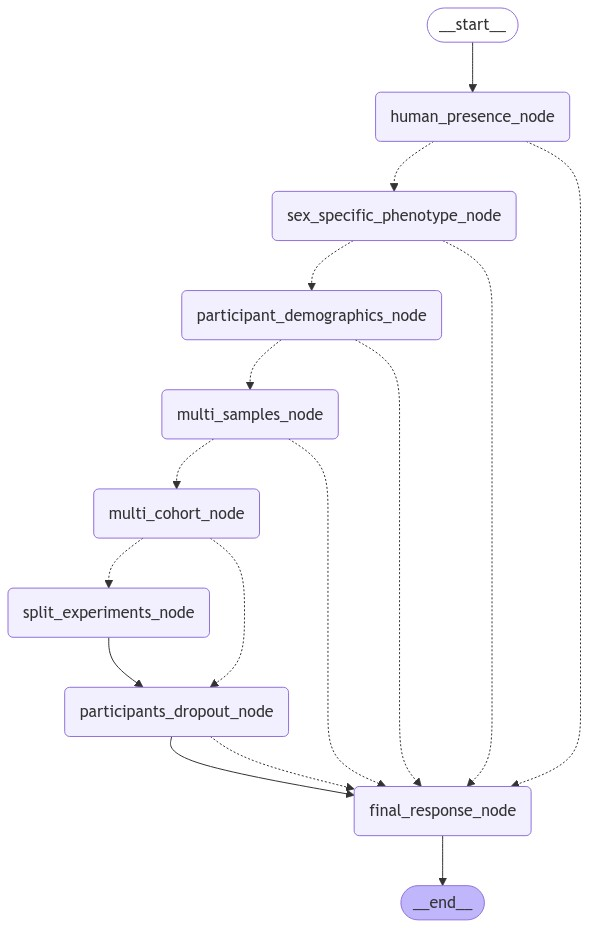

In [50]:
graph = StateGraph(ResultResponse, input=DecisionState, output=FinalResponse)

graph.add_edge(START, "human_presence_node")

graph.add_node('human_presence_node', human_presence)

graph.add_node("sex_specific_phenotype_node", sex_specific_phenotype)

graph.add_node("participant_demographics_node", participant_demographics)

graph.add_node("multi_samples_node", multi_samples)

graph.add_node("multi_cohort_node", multi_cohort)

graph.add_node('split_experiments_node', split_experiments)

graph.add_node("participants_dropout_node", participants_dropout)



graph.add_node('final_response_node', final_response)

graph.add_edge('participants_dropout_node', 'final_response_node')
graph.add_edge('split_experiments_node', "participants_dropout_node")

graph.add_edge("final_response_node", END)

graph = graph.compile()
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [51]:
for article in tqdm.tqdm(pmcid_method):
    initial_state = DecisionState(article=article)  # Call the initial_state like that otherwise DecisionState is not populated with default values
    result = graph.invoke(initial_state)  
    print(f"Final answer: {result}")
 

  0%|                                                                                                                                                                                                                                                                                                   | 0/10 [00:08<?, ?it/s]


NameError: name 'node' is not defined

### 

In [ ]:
# Example inputs to validate
weird_string_test = '```json\n{\n  "answer": True\n}\n```'

inputs = [
    {"answer": "False"},                       # String "False"
    {"answer": "True"},                        # String "True"
    {"answer": "true"},                        # Case-insensitive "true"
    {"answer": "false"},                       # Case-insensitive "false"
    {"answer": '{"answer": "True"}'},          # JSON with nested "True" as string
    {"answer": '{"answer": true}'},            # JSON with boolean true
    {"answer": "True   "},                     # String with extra whitespace
    {"answer": "False   "},                    # String with extra whitespace
    {"answer": "Not a boolean"},               # Invalid string
    {"answer": '{"answer": "Not a boolean"}'}, # Nested invalid value
    {"answer": '{"answer": false}'},           # Nested valid boolean false
    {"answer": True},                          # Python-style True
    {"answer": False},                         # Python-style False
    {"answer": None},                          # None input
    {"answer": weird_string_test},             # Weird string with JSON-like content
]

# Test each input
for i, input_data in enumerate(inputs):
    try:
        print(f"Testing input {i + 1}: {input_data}")
        result = BooleanParser(**input_data)
        print(f"Test case {i+1}: {input_data} -> Parsed: {result}")
    except ValueError as e:
        print(f"Test case {i+1}: {input_data} -> Error: {e}")
    except Exception as e:
        print(f"Test case {i+1}: {input_data} -> Unexpected Error: {e}")